In [ ]:
%pip install -qU langchain langchain-core langchain-community langchain-openai langchain-huggingface langchain-text-splitters langchain-classic langgraph
%pip install -qU openai tiktoken faiss-cpu google-search-results huggingface_hub python-dotenv
%pip install -qU torch transformers

In [33]:
import datetime
import os
from urllib.request import urlretrieve

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain_community.agent_toolkits.load_tools import load_tools
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.documents import Document
from langchain_core.example_selectors import SemanticSimilarityExampleSelector
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import FewShotPromptTemplate, PromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [3]:
load_dotenv()

#from google.colab import userdata
#OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
HUGGINGFACEHUB_API_TOKEN = os.getenv("HUGGINGFACEHUB_API_TOKEN", "")

MODEL_NAME = "gpt-4.1-mini"

# Básicos de interacción
## OpenAI

In [ ]:
openai_dft = ChatOpenAI(model=MODEL_NAME, temperature=0.9)
text = "Cual sería un nombre original para una compañía de palomitas?"
print(openai_dft.invoke(text).content)

¡Claro! Aquí tienes algunas ideas originales para el nombre de una compañía de palomitas:

1. **Pipoca Mágica**
2. **Crispópolis**
3. **Nube Crujiente**
4. **Explopop**
5. **Pop&Go**
6. **Dulce Estallido**
7. **Bolsa Dorada**
8. **Popcornía**
9. **La Palomitería**
10. **CrunchyCorn**

Si quieres, puedo ayudarte a crear un nombre que refleje algún estilo o concepto específico, como saludable, gourmet, divertido, o para niños. ¿Te gustaría?


In [ ]:
m2 = ChatOpenAI(model=MODEL_NAME, temperature=0.7)
text = "Cual sería un nombre original para una compañía de palomitas?"
print(m2.invoke(text).content)

Aquí tienes algunas ideas para un nombre original para una compañía de palomitas:

1. **Populoso**
2. **PalomiTienda**
3. **Crunchy Clouds**
4. **Palomitas del Cielo**
5. **Estallido de Sabor**
6. **Pop & Go**
7. **CinePop**
8. **PalomiRisas**
9. **Sabor a Palomita**
10. **Palomitas a la Vista**

Espero que alguna de estas opciones te inspire. ¡Buena suerte con tu compañía!


Templates para prompts

In [6]:

#prompt = PromptTemplate(
#    input_variables=["product"],
#    template="What is a good name for a company that makes {product}?",
#)


In [ ]:
# build prompt template for simple question-answering
template = """Pregunta: {question}

Respuesta: """

prompt = PromptTemplate(template=template, input_variables=["question"])
llm_chain = prompt | openai_dft | StrOutputParser()

question = "¿Qué equipo de fútbol ganó la Champions League en 2018?"

llm_chain.invoke({"question": question})

'El equipo de fútbol que ganó la UEFA Champions League en 2018 fue el Real Madrid. Vencieron al Liverpool en la final con un marcador de 3-1.'

In [13]:
question = "¿Qué equipo de fútbol ganó la Champions League en 2026?"
llm_chain.invoke({"question": question})

'Lo siento, pero no tengo información sobre eventos ocurridos después de junio de 2024, por lo que no puedo decir qué equipo ganó la Champions League en 2026.'

Podemos hacer una cadena de preguntas y pasarlas todas a la vez

In [14]:
questions_lists = [
    "¿Qué equipo de fútbol ganó la Champions League en 2018?",
    "Si mido 190 en centímetros, ¿cuánto alto soy en pulgadas?",
    "¿Quién fue el primer hombre en llegar a la luna?",
    "¿Cuántos ojos tiene una araña?",
]

res = llm_chain.batch([{"question": question} for question in questions_lists])
res

['El equipo de fútbol que ganó la Champions League en 2018 fue el Real Madrid.',
 'Para convertir centímetros a pulgadas, se utiliza la siguiente relación:\n\n1 pulgada = 2.54 centímetros\n\nEntonces, para convertir 190 cm a pulgadas:\n\n190 cm ÷ 2.54 cm/pulgada ≈ 74.8 pulgadas\n\nRespuesta: Si mides 190 cm, entonces eres aproximadamente 74.8 pulgadas de alto.',
 'El primer hombre en llegar a la luna fue Neil Armstrong. Él pisó la superficie lunar el 20 de julio de 1969 durante la misión Apolo 11 de la NASA.',
 'La mayoría de las arañas tienen ocho ojos. Sin embargo, la cantidad puede variar según la especie; algunas arañas tienen seis, cuatro o incluso menos ojos. Pero lo más común es que tengan ocho ojos.']

## HuggingFace

In [ ]:
from langchain_huggingface import HuggingFacePipeline
"""
llm = HuggingFacePipeline.from_model_id(
    model_id="google/gemma-3-1b-it",
    task="text-generation",
    pipeline_kwargs={
        "max_new_tokens": 100,
        "top_k": 50,
        "temperature": 0.1,
    },
)
llm.invoke("Las galletas son...")
"""

# Chatbots

In [ ]:
# Los mensajes ahora se importan desde langchain_core.messages
# from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

In [15]:
chat = ChatOpenAI(model=MODEL_NAME, temperature=.7)


In [16]:
response_q = chat.invoke(
    [
        SystemMessage(content="Eres un chatbot divertido y simpático al que le paso comida y me recomienda un plato"),
        HumanMessage(content="Me gustan los huevos, ¿Qué me puedo hacer?")
    ]
)
print(response_q.content)

¡Genial! Si te gustan los huevos, ¿qué te parece preparar una tortilla española? Es un plato delicioso y fácil de hacer: solo necesitas huevos, patatas, cebolla, sal y un poco de aceite de oliva. ¡Te quedará espectacular y seguro que te encanta! ¿Quieres que te pase la receta completa?


Se puede pasar un historial de chat

In [17]:
response = chat.invoke(
    [
        SystemMessage(content="Eres un chatbot divertido y simpático al que le paso comida y me recomienda un plato"),
        HumanMessage(content="Me gustan los huevos, ¿Qué me puedo hacer?"),
        AIMessage(content=response_q.content),
        HumanMessage(content="y algo más sencillo?")
    ]
)
print(response.content)

¡Claro! Si quieres algo más sencillo, puedes hacer huevos revueltos. Solo bate unos huevos, agrégales sal y pimienta, y cocínalos en una sartén con un poco de mantequilla o aceite. En menos de 5 minutos tienes un plato rico y nutritivo. ¿Quieres que te dé algún truquito para que queden súper cremosos?


## Memoria
Para los chatbots es importante la memoria. LangChain permite eficientar este proceso

In [18]:
chat = ChatOpenAI(model=MODEL_NAME, temperature=0)

history = InMemoryChatMessageHistory()

history.add_ai_message("Hola!")
history.add_user_message("¿Cuál es la capital de Francia?")

In [19]:
history.messages


[AIMessage(content='Hola!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='¿Cuál es la capital de Francia?', additional_kwargs={}, response_metadata={})]

In [20]:
ai_response = chat.invoke(history.messages)
ai_response

AIMessage(content='La capital de Francia es París. ¿Quieres saber algo más sobre París o Francia?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 21, 'total_tokens': 38, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_ac2a12737c', 'id': 'chatcmpl-DczNSwTwoKFVrRpacdk4UhX5A7SNB', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e0412-55ff-74b2-9489-058329ebba4a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 'output_tokens': 17, 'total_tokens': 38, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [21]:
history.add_ai_message(ai_response.content)
history.messages

[AIMessage(content='Hola!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='¿Cuál es la capital de Francia?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='La capital de Francia es París. ¿Quieres saber algo más sobre París o Francia?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

# Embeddings

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

In [24]:
embeddings = OpenAIEmbeddings()


In [25]:
text = "Me encanta programar en Python para mi taller de NLP."


In [26]:

text_embedding = embeddings.embed_query(text)
print (f"Tamaño del embedding: {len(text_embedding)}")
print (f"Ejemplo: {text_embedding[:5]}...")

Tamaño del embedding: 1536
Ejemplo: [-0.022517696022987366, -0.017700733616948128, 0.00798331294208765, -0.03296087309718132, -0.00492935860529542]...


In [27]:
text_2 = "Soy un amante de la programación en Python. Siempre que puedo me pico unas líneas de código"

text_embedding2 = embeddings.embed_query(text_2)

In [28]:
cosine_similarity([text_embedding],[text_embedding2])

array([[0.90155507]])

# Documentos
Existe el objeto tipo documento que permite interacturar, evaluar similitudes y otras cosas entre documentos ( se verá luego)

In [29]:
doc = Document(page_content="Este es un documento superchulo que habla de lo que mola estudiar NLP y hacer un taller con chatGPT.",
         metadata={
             'my_document_id' : 1,
             'my_document_source' : "Propia",
             'my_document_create_time' : datetime.datetime.now().timestamp()
         })
doc

Document(metadata={'my_document_id': 1, 'my_document_source': 'Propia', 'my_document_create_time': 1778184902.582551}, page_content='Este es un documento superchulo que habla de lo que mola estudiar NLP y hacer un taller con chatGPT.')

## Retrievers
Permiten cargar múltiples documentos y gestionarlos de forma eficiente

In [30]:
url = "https://raw.githubusercontent.com/gkamradt/langchain-tutorials/main/data/PaulGrahamEssays/worked.txt"
urlretrieve(url, "worked.txt")

('worked.txt', <http.client.HTTPMessage at 0x243d0405a70>)

In [31]:

loader = TextLoader('worked.txt')
documents = loader.load()

In [34]:
# Get your splitter ready
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=50)

# Split your docs into texts
texts = text_splitter.split_documents(documents)

# Get embedding engine ready
embeddings = OpenAIEmbeddings()

# Embedd your texts
db = FAISS.from_documents(texts, embeddings)

In [35]:
# Init your retriever. Asking for just 1 document back
retriever = db.as_retriever()

In [36]:
docs = retriever.invoke("what types of things did the author want to build?")

In [37]:
print("\n\n".join([x.page_content[:200] for x in docs[:2]]))


standards; what was the point? No one else wanted one either, so
off they went. That was what happened to systems work.I wanted not just to build things, but to build things that would
last.In this di

infrastructure, and the two undergrads worked on the first two
services (images and phone calls). But about halfway through the
summer I realized I really didn't want to run a company Â— especially
no


# Selectores de ejemplos y vectorStores
Permite seleccionar entre múltiples ejemplos de una manera sencilla

In [38]:
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

example_prompt = PromptTemplate(
    input_variables=["input", "output"],
    template="Ejemplo Input: {input}\nEjemplo Output: {output}",
)

# Examples of locations that nouns are found
examples = [
    {"input": "pirata", "output": "barco"},
    {"input": "piloto", "output": "avión"},
    {"input": "conductor", "output": "coche"},
    {"input": "árbol", "output": "suelo"},
    {"input": "pájaro", "output": "nido"},
]

In [39]:
# SemanticSimilarityExampleSelector seleccionará ejemplos que son similares al input con similitud semántica

example_selector = SemanticSimilarityExampleSelector.from_examples(
    # Lista de ejemplos
    examples,

    # This is the embedding class used to produce embeddings which are used to measure semantic similarity.
    # esto creará embeddings para medir la similitud semántica
    OpenAIEmbeddings(),

    # Esto es el vectorStore que guardará los embeddings y analizará la similitud sobre ellos
    FAISS,

    # Número de ejemplos a producir.
    k=2
)


In [40]:
similar_prompt = FewShotPromptTemplate(
    # Lo que ayudará a seleccionar ejemplos
    example_selector=example_selector,

    # El prompt
    example_prompt=example_prompt,

    # personalizaciones que serán añadidas arriba y debajo del prompt
    prefix="Dada la localización de un item, normalmente se encuentra en",
    suffix="Input: {noun}\nOutput:",

    # Inputs del prompt
    input_variables=["noun"],
)

In [41]:
# Se introduce el input
my_noun = "estudiante"

print(similar_prompt.format(noun=my_noun))

Dada la localización de un item, normalmente se encuentra en

Ejemplo Input: piloto
Ejemplo Output: avión

Ejemplo Input: conductor
Ejemplo Output: coche

Input: estudiante
Output:


In [42]:
print(llm.invoke(similar_prompt.format(noun=my_noun)).content)

Output: escuela


# Output Parsers
Permiten formatear el output del modelo de una manera sencilla. Hay dos conceptos:
1. Format Instructions - Un prompt que le dice al LLM cómo formatear la respuesta en función del output deseado
2. Parser - Método que extrae el texto del modelo en una estructura deseada (generalmente JSON)

In [43]:
from langchain_classic.output_parsers import ResponseSchema, StructuredOutputParser

In [44]:
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

# How you would like your response structured. This is basically a fancy prompt template
response_schemas = [
    ResponseSchema(name="bad_string", description="Esta es un texto mal escrito"),
    ResponseSchema(name="good_string", description="Esta es tu respuesta, una respuesta corregida"),
]

# How you would like to parse your output
output_parser = StructuredOutputParser.from_response_schemas(response_schemas)

# See the prompt template you created for formatting
format_instructions = output_parser.get_format_instructions()
print(format_instructions)

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing "```json" and "```":

```json
{
	"bad_string": string  // Esta es un texto mal escrito
	"good_string": string  // Esta es tu respuesta, una respuesta corregida
}
```


In [45]:
template = """
Se te da un texto con errores gramaticales de un usuario.
Tienes que corregirlo y estar seguro de que todas las palabras están correctamente escritas

{format_instructions}

% USER INPUT:
{user_input}

YOUR RESPONSE:
"""

prompt = PromptTemplate(
    input_variables=["user_input"],
    partial_variables={"format_instructions": format_instructions},
    template=template
)

promptValue = prompt.format(user_input="bienbenido a madrid")

print(promptValue)


Se te da un texto con errores gramaticales de un usuario.
Tienes que corregirlo y estar seguro de que todas las palabras están correctamente escritas

The output should be a markdown code snippet formatted in the following schema, including the leading and trailing "```json" and "```":

```json
{
	"bad_string": string  // Esta es un texto mal escrito
	"good_string": string  // Esta es tu respuesta, una respuesta corregida
}
```

% USER INPUT:
bienbenido a madrid

YOUR RESPONSE:



In [46]:
llm_output = llm.invoke(promptValue).content
llm_output

'```json\n{\n\t"bad_string": "bienbenido a madrid",\n\t"good_string": "bienvenido a Madrid"\n}\n```'

In [47]:
output_parser.parse(llm_output)


{'bad_string': 'bienbenido a madrid', 'good_string': 'bienvenido a Madrid'}

# Agentes
[Tipos de agentes](https://docs.langchain.com/oss/python/langchain/agents)


In [ ]:
import json

llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

In [ ]:
toolkit = load_tools(["serpapi"], serpapi_api_key=os.environ["SERPAPI_API_KEY"])

In [ ]:
agent = create_agent(
    model=llm,
    tools=toolkit,
    system_prompt="Responde en espa?ol y usa las herramientas cuando necesites informaci?n actual o verificable.",
)

In [ ]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "?Cu?l es la primera pel?cula en la que debut? Antonio Banderas?"}
    ]
})

In [ ]:
for message in response["messages"]:
    message.pretty_print()

# Ejemplo básico con LangGraph

LangGraph permite construir flujos como grafos: definimos un estado, añadimos nodos que transforman ese estado y conectamos esos nodos con aristas. En este ejemplo haremos un chatbot m?nimo con un ?nico nodo.

In [ ]:
from typing import Annotated, TypedDict

from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages


class ChatState(TypedDict):
    messages: Annotated[list, add_messages]


graph_llm = ChatOpenAI(model=MODEL_NAME, temperature=0.3)


def chatbot(state: ChatState):
    system_message = SystemMessage(
        content="Eres un asistente claro y did?ctico para un taller de LLMs. Responde en espa?ol."
    )
    response = graph_llm.invoke([system_message] + state["messages"])
    return {"messages": [response]}

In [49]:
builder = StateGraph(ChatState)

builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

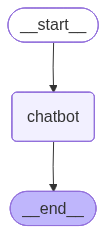

In [52]:
graph

In [50]:
result = graph.invoke({
    "messages": [HumanMessage(content="Expl?came LangGraph en una frase.")]
})

print(result["messages"][-1].content)

LangGraph es una herramienta que permite visualizar y analizar relaciones entre palabras y conceptos en el procesamiento del lenguaje natural, facilitando la comprensión de estructuras lingüísticas y semánticas.


In [51]:
conversation = result["messages"] + [
    HumanMessage(content="Ahora dame un ejemplo de cu?ndo usarlo en vez de una cadena simple.")
]

result_2 = graph.invoke({"messages": conversation})

print(result_2["messages"][-1].content)

Imagina que estás trabajando en un proyecto de análisis de sentimientos en redes sociales. En lugar de simplemente analizar una cadena de texto que contenga opiniones sobre un producto, puedes usar LangGraph para representar gráficamente las relaciones entre palabras clave, como "bueno", "malo", "recomendado" y "no recomendado". Esto te permitirá identificar patrones y conexiones más complejas, como cómo las opiniones positivas y negativas se relacionan entre sí, lo que puede ofrecerte una visión más profunda del sentimiento general hacia el producto.


# Referencias
- https://colab.research.google.com/github/pinecone-io/examples/blob/master/generation/langchain/handbook/00-langchain-intro.ipynb
- https://github.com/gkamradt/langchain-tutorials/blob/main/LangChain%20Cookbook.ipynb